In [12]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Import plotting functions from graphs.py
from graphs import (
    load_runs,
    plot_requests_per_second,
    plot_batch_times,
    get_requests_per_second,
    _batch_elapsed,
    _build_color_map,
    _collect_model_names,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration
Select which runs and baselines to load, and toggle display options.

In [63]:
# Directories
BASELINES_DIR = Path("baselines")
RUNS_DIR = Path("runs")

# Display options
INCLUDE_REBALANCE_TIME = False  # include rebalance time in elapsed calculations
SHOW_REBALANCE = False          # show vertical rebalance event lines
SHOW_OPTIMUM = True             # show optimum markers

# Optimizer state graphs
SHOW_COMBINED_GAMMA = True      # deep_gamma + sibling_gamma * deep_alpha
SHOW_DEEP_GAMMA = False         # deep_gamma only
SHOW_SIBLING_GAMMA = False      # sibling_gamma only
SHOW_OPTIMUM_ESCAPE = True      # whether optimizer is in escape state

# Filter runs and baselines (set to None to load all, or a list like ["run20", "run21"])
SELECTED_RUNS = ['run37', 'run41'] # run41 is best so far, with 37 a close second
SELECTED_BASELINES = ['tensor_parallel', 'gpipe_4x8']

In [64]:
# Load data
all_baselines = load_runs(BASELINES_DIR)
all_runs = load_runs(RUNS_DIR)

if SELECTED_RUNS is not None:
    runs = {k: v for k, v in all_runs.items() if k in SELECTED_RUNS}
else:
    runs = all_runs

if SELECTED_BASELINES is not None:
    baselines = {k: v for k, v in all_baselines.items() if k in SELECTED_BASELINES}
else:
    baselines = all_baselines

print(f"Loaded {len(baselines)} baselines: {list(baselines.keys())}")
print(f"Loaded {len(runs)} runs: {list(runs.keys())}")

Loaded 2 baselines: ['gpipe_4x8', 'tensor_parallel']
Loaded 2 runs: ['run37', 'run41']


## Throughput (Requests per Second)

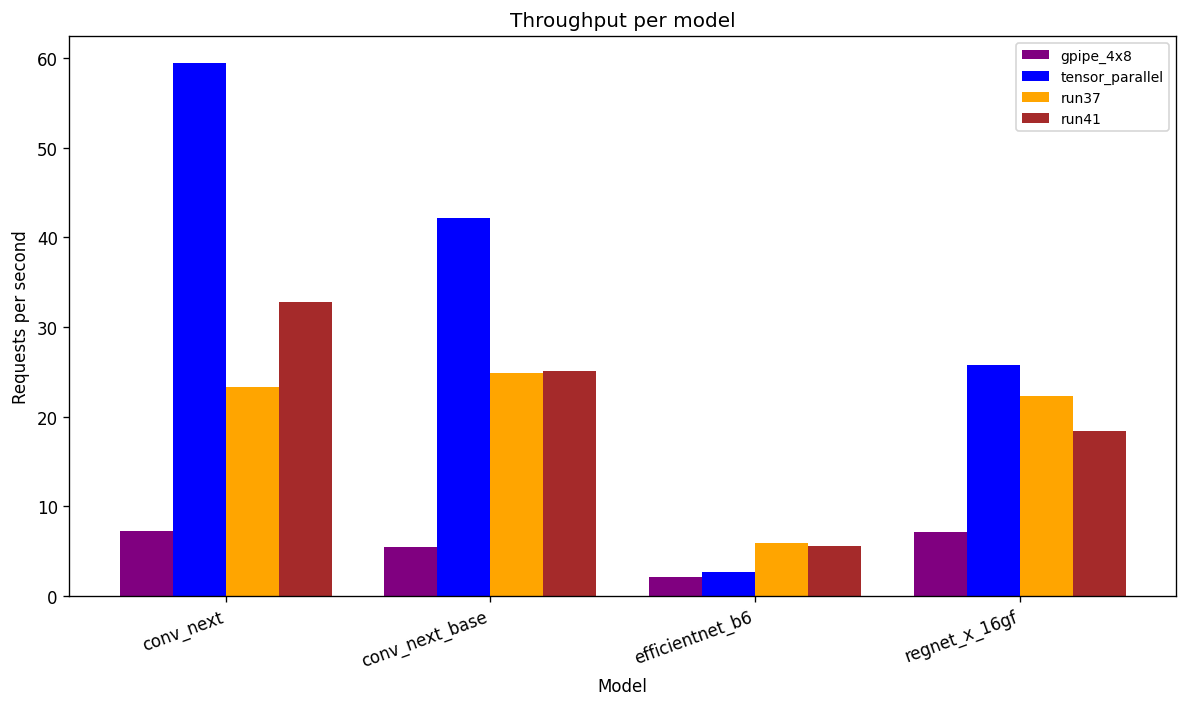

In [65]:
plot_requests_per_second(baselines, runs, include_rebalance=INCLUDE_REBALANCE_TIME)

## Batch Times

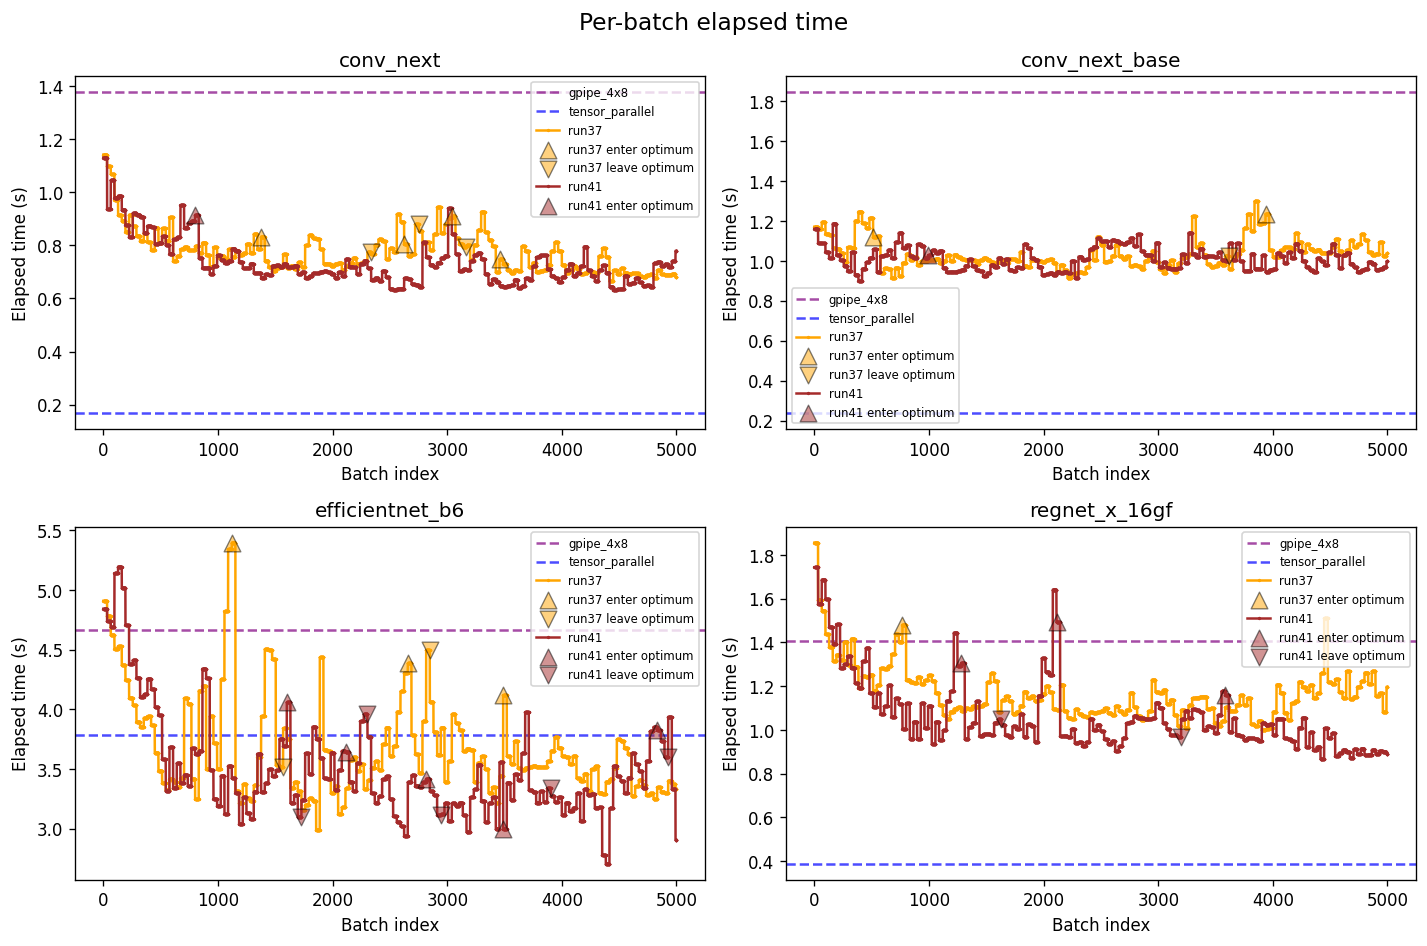

In [66]:
from graphs import _get_rebalance_events, _legend_kwargs

model_names = _collect_model_names(baselines, runs)
colors = _build_color_map(baselines, runs)

n_models = len(model_names)
cols = min(n_models, 2)
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)

for idx, model in enumerate(model_names):
    ax = axes[idx // cols][idx % cols]

    # Baselines as horizontal dashed lines
    for ds_name, ds in baselines.items():
        if model not in ds["results"]:
            continue
        batches = ds["results"][model].get("batches", [])
        elapsed = [_batch_elapsed(b, INCLUDE_REBALANCE_TIME) for b in batches if "timing" in b]
        if elapsed:
            mean_elapsed = sum(elapsed) / len(elapsed)
            ax.axhline(mean_elapsed, color=colors[ds_name], linestyle="--", alpha=0.7, label=ds_name)

    # Runs as line plots
    for ds_name, ds in runs.items():
        if model not in ds["results"]:
            continue
        batches = ds["results"][model].get("batches", [])
        elapsed = [_batch_elapsed(b, INCLUDE_REBALANCE_TIME) for b in batches if "timing" in b]
        if not elapsed:
            continue
        color = colors[ds_name]
        ax.plot(range(len(elapsed)), elapsed, color=color, label=ds_name, marker=".", markersize=2)

        # Rebalance lines (last subplot only)
        if SHOW_REBALANCE and idx == n_models - 1:
            for j, ev in enumerate(_get_rebalance_events(batches)):
                ax.axvline(ev, color=color, linestyle=":", alpha=0.3,
                           label=f"{ds_name} rebalance" if j == 0 else None)

        # Optimum enter/leave markers
        if SHOW_OPTIMUM:
            opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in batches]
            enters = []
            leaves = []
            for i in range(len(opt_flags)):
                prev = opt_flags[i - 1] if i > 0 else False
                if opt_flags[i] and not prev:
                    enters.append(i)
                elif not opt_flags[i] and prev:
                    leaves.append(i - 1)

            if enters:
                enter_ys = [elapsed[i] for i in enters if i < len(elapsed)]
                enter_xs = [i for i in enters if i < len(elapsed)]
                ax.scatter(enter_xs, enter_ys, color=color, marker="^", s=100,
                           alpha=0.5, edgecolors="black", linewidths=0.8, zorder=5,
                           label=f"{ds_name} enter optimum" if enter_xs else None)
            if leaves:
                leave_ys = [elapsed[i] for i in leaves if i < len(elapsed)]
                leave_xs = [i for i in leaves if i < len(elapsed)]
                ax.scatter(leave_xs, leave_ys, color=color, marker="v", s=100,
                           alpha=0.5, edgecolors="black", linewidths=0.8, zorder=5,
                           label=f"{ds_name} leave optimum" if leave_xs else None)

    ax.set_title(model)
    ax.set_xlabel("Batch index")
    ax.set_ylabel("Elapsed time (s)")
    ax.legend(fontsize="x-small")

for idx in range(n_models, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

fig.suptitle("Per-batch elapsed time", fontsize=14)
fig.tight_layout()
plt.show()

## Run Summary Table

In [67]:
for run_name, run_data in sorted(runs.items()):
    meta = run_data.get("meta", {})
    commit = meta.get("git_commit", "?")[:8]
    n_requests = meta.get("num_requests", "?")
    optimizer = meta.get("optimizer", "?")
    opt_kwargs = meta.get("optimizer_kwargs", {})
    interval = opt_kwargs.get("rebalance_interval") or meta.get("rebalance_interval", "?")
    deep_alpha = opt_kwargs.get("deep_alpha", "?")
    sibling_alpha = opt_kwargs.get("sibling_alpha", "?")
    tolerance = opt_kwargs.get("tolerance", "?")
    optimum_tolerance = opt_kwargs.get("optimum_tolerance", "?")
    optimum_escape = opt_kwargs.get("optimum_escape_duration", opt_kwargs.get("optimum_escape", "-"))

    print(f"=== {run_name} === commit: {commit}")
    print(f"  optimizer: {optimizer}, interval: {interval}, requests: {n_requests}")
    print(f"  deep_alpha: {deep_alpha}, sibling_alpha: {sibling_alpha}, tolerance: {tolerance}, optimum_tolerance: {optimum_tolerance}, optimum_escape: {optimum_escape}")
    for model, result in run_data["results"].items():
        batches = result.get("batches", [])
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        rps = result.get("requests_per_second", 0)
        print(f"  {model}: rps={rps:.2f}, rebalances={rebalances}, at_optimum={at_optimum}")

        # Find contiguous optimum intervals
        if at_optimum > 0:
            intervals = []
            start = None
            for i, b in enumerate(batches):
                is_opt = b.get("rebalance", {}).get("at_optimum", False)
                if is_opt and start is None:
                    start = i
                elif not is_opt and start is not None:
                    intervals.append((start, i - 1))
                    start = None
            if start is not None:
                intervals.append((start, len(batches) - 1))
            print(f"    optimum intervals ({len(intervals)}): {intervals}")
    print()

=== run37 === commit: 4453b9b1
  optimizer: TimeBasedShishaPipelineOptimizer, interval: 3, requests: 5000
  deep_alpha: 5, sibling_alpha: 2, tolerance: 0.02, optimum_tolerance: 0.1, optimum_escape: 4
  conv_next: rps=23.26, rebalances=2368, at_optimum=2760
    optimum intervals (4): [(1376, 2335), (2624, 2751), (3040, 3167), (3456, 4999)]
  conv_next_base: rps=24.92, rebalances=896, at_optimum=4168
    optimum intervals (2): [(512, 3615), (3936, 4999)]
  efficientnet_b6: rps=5.86, rebalances=2944, at_optimum=2152
    optimum intervals (3): [(1120, 1567), (2656, 2847), (3488, 4999)]
  regnet_x_16gf: rps=22.34, rebalances=800, at_optimum=4232
    optimum intervals (1): [(768, 4999)]

=== run41 === commit: 4bcc3a07
  optimizer: TimeBasedShishaPipelineOptimizer, interval: 3, requests: 5000
  deep_alpha: 5, sibling_alpha: 2, tolerance: 0.02, optimum_tolerance: 0.08, optimum_escape: 7.0
  conv_next: rps=32.78, rebalances=832, at_optimum=4200
    optimum intervals (1): [(800, 4999)]
  conv_ne

## Optimizer State Over Time
Plot deep_gamma and sibling_gamma for runs that include optimizer state data.

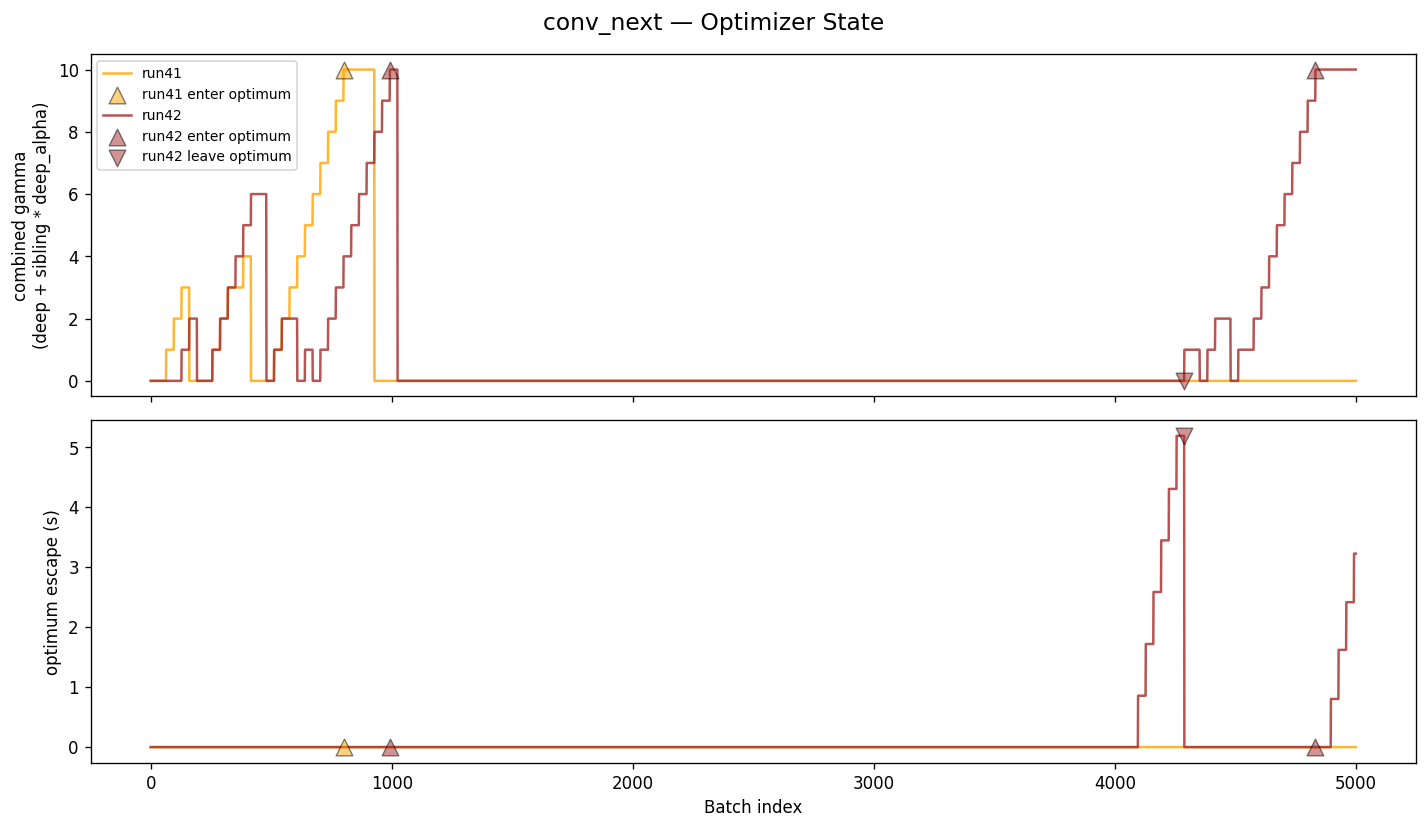

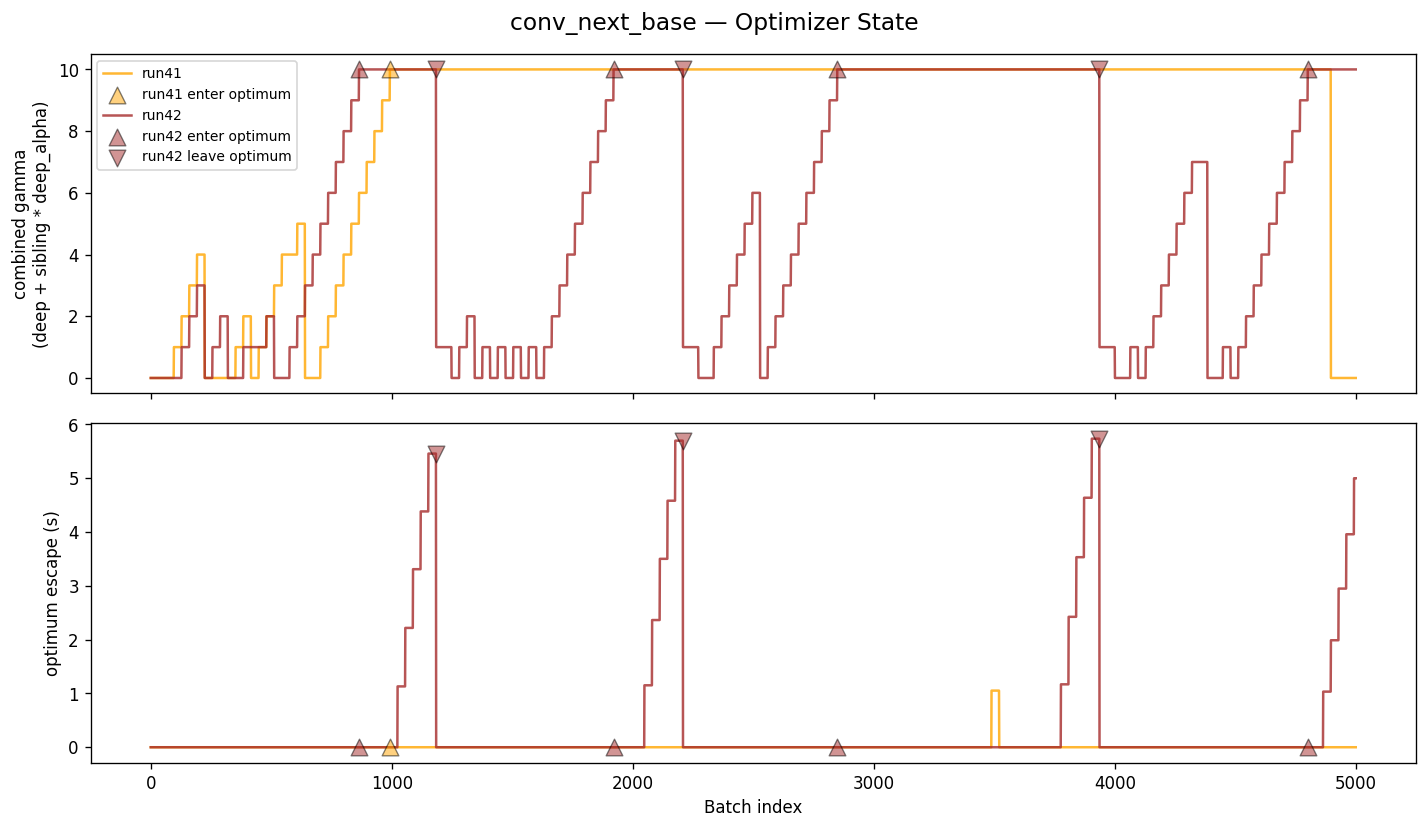

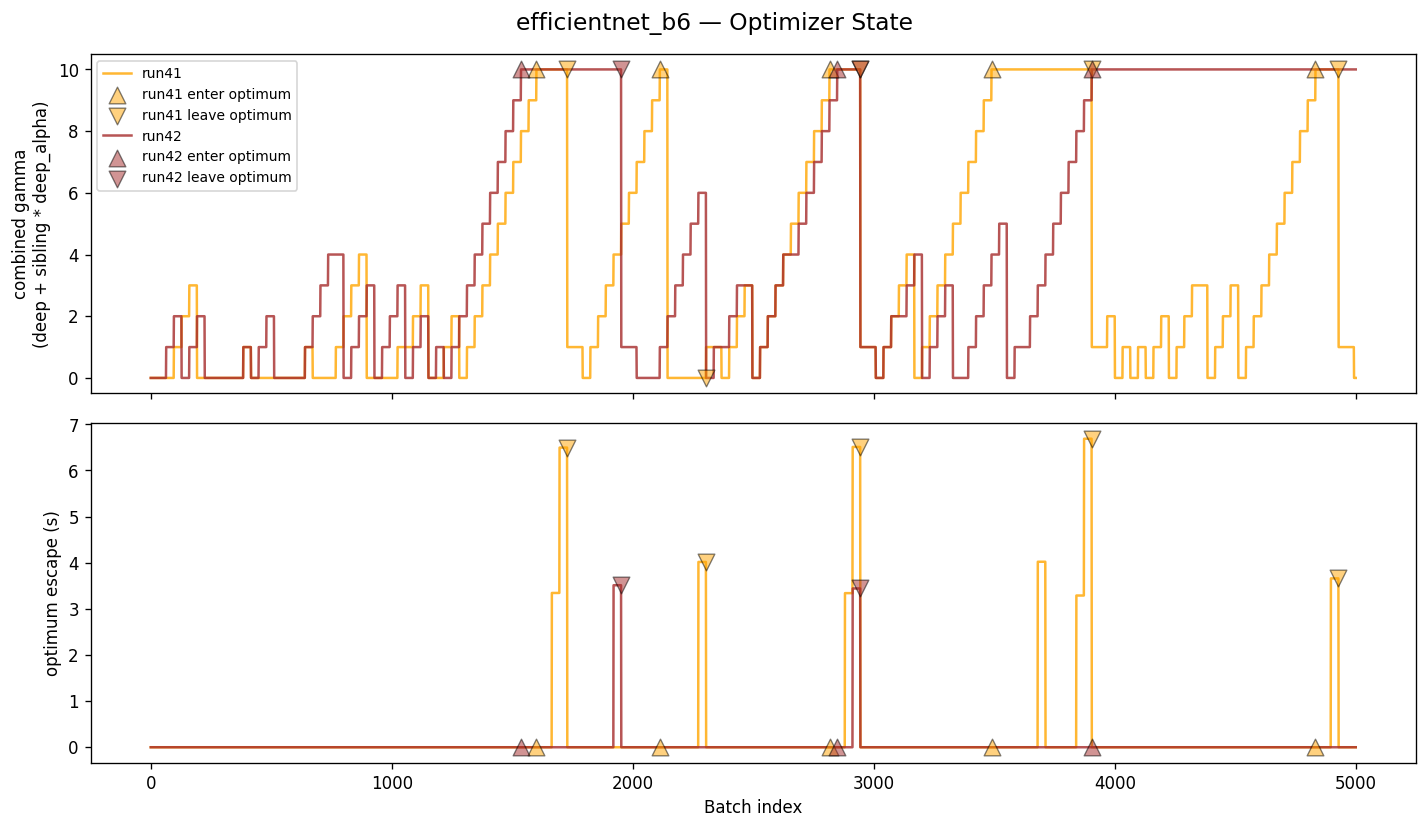

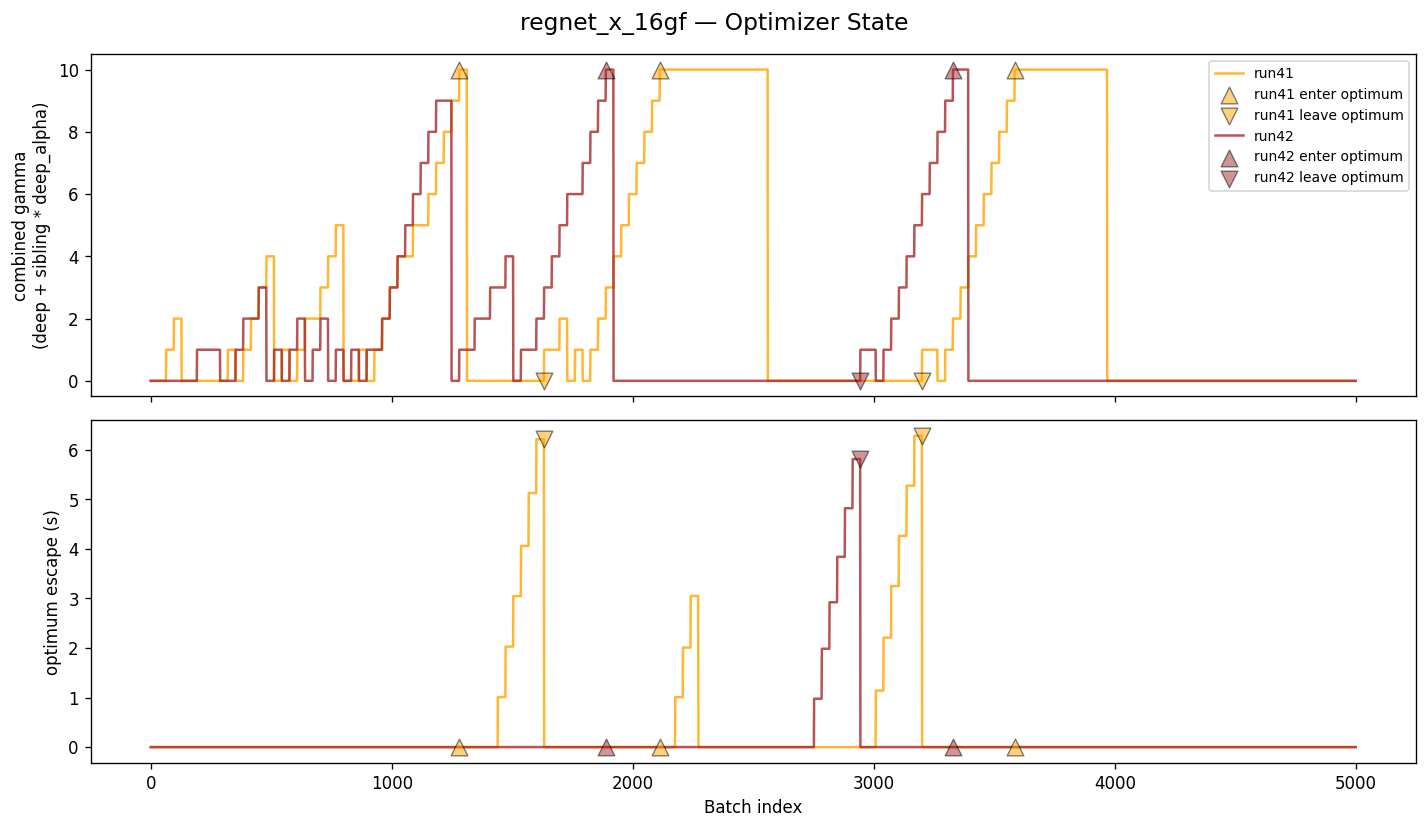

In [58]:
model_names = _collect_model_names(baselines, runs)
colors = _build_color_map(baselines, runs)

# Build list of subplots to show
gamma_plots = []
if SHOW_COMBINED_GAMMA:
    gamma_plots.append(("combined gamma\n(deep + sibling * deep_alpha)", "combined"))
if SHOW_DEEP_GAMMA:
    gamma_plots.append(("deep_gamma", "deep"))
if SHOW_SIBLING_GAMMA:
    gamma_plots.append(("sibling_gamma", "sibling"))
if SHOW_OPTIMUM_ESCAPE:
    gamma_plots.append(("optimum escape (s)", "escape_elapsed"))

if not gamma_plots:
    print("No optimizer state graphs enabled")
else:
    for model in model_names:
        n_plots = len(gamma_plots)
        fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3 * n_plots + 1), sharex=True, squeeze=False)
        fig.suptitle(f"{model} — Optimizer State", fontsize=14)

        for run_name, run_data in runs.items():
            if model not in run_data["results"]:
                continue
            batches = run_data["results"][model].get("batches", [])
            deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
            sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]

            # Support both old (optimum_escape_i counter) and new (optimum_escape_elapsed seconds) formats
            escape_elapsed = []
            for b in batches:
                reb = b.get("rebalance", {})
                if "optimum_escape_elapsed" in reb:
                    escape_elapsed.append(reb["optimum_escape_elapsed"] or 0.0)
                elif "optimum_escape_i" in reb:
                    escape_elapsed.append(reb["optimum_escape_i"] or 0)
                else:
                    escape_elapsed.append(None)

            if not any(v is not None for v in deep_gamma):
                continue

            opt_kwargs = run_data.get("meta", {}).get("optimizer_kwargs", {})
            deep_alpha = opt_kwargs.get("deep_alpha", 5)

            # Precompute all series
            series = {
                "combined": [
                    (d or 0) + (s or 0) * deep_alpha
                    if d is not None and s is not None else None
                    for d, s in zip(deep_gamma, sibling_gamma)
                ],
                "deep": deep_gamma,
                "sibling": sibling_gamma,
                "escape_elapsed": escape_elapsed,
            }

            # Optimum enter/exit
            opt_flags = [b.get("rebalance", {}).get("at_optimum", False) for b in batches]
            enters = []
            leaves = []
            for i in range(len(opt_flags)):
                prev = opt_flags[i - 1] if i > 0 else False
                if opt_flags[i] and not prev:
                    enters.append(i)
                elif not opt_flags[i] and prev:
                    leaves.append(i - 1)

            xs = range(len(batches))
            color = colors.get(run_name, "white")

            for plot_idx, (ylabel, key) in enumerate(gamma_plots):
                ax = axes[plot_idx][0]
                data = series[key]
                ax.plot(xs, data, color=color, label=run_name, alpha=0.8, markersize=2)

                is_first = plot_idx == 0
                if enters:
                    enter_xs = [i for i in enters if i < len(data) and data[i] is not None]
                    enter_ys = [data[i] for i in enter_xs]
                    ax.scatter(enter_xs, enter_ys, color=color, marker="^", s=100,
                               alpha=0.5, edgecolors="black", linewidths=0.8, zorder=5,
                               label=f"{run_name} enter optimum" if is_first and enter_xs else None)
                if leaves:
                    leave_xs = [i for i in leaves if i < len(data) and data[i] is not None]
                    leave_ys = [data[i] for i in leave_xs]
                    ax.scatter(leave_xs, leave_ys, color=color, marker="v", s=100,
                               alpha=0.5, edgecolors="black", linewidths=0.8, zorder=5,
                               label=f"{run_name} leave optimum" if is_first and leave_xs else None)

        for plot_idx, (ylabel, _) in enumerate(gamma_plots):
            ax = axes[plot_idx][0]
            ax.set_ylabel(ylabel)
            if plot_idx == 0:
                ax.legend(fontsize="small")
        axes[-1][0].set_xlabel("Batch index")
        fig.tight_layout()
        plt.show()